<a href="https://colab.research.google.com/github/427paul/AI_Agent/blob/main/6%E1%84%8C%E1%85%AE%E1%84%8E%E1%85%A1_%E1%84%90%E1%85%A6%E1%86%A8%E1%84%89%E1%85%B3%E1%84%90%E1%85%B3%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8_%E1%84%83%E1%85%B5%E1%86%B8%E1%84%85%E1%85%A5%E1%84%82%E1%85%B5%E1%86%BC%E1%84%80%E1%85%B5%E1%84%8E%E1%85%A9_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## 📝 과제

### 과제 1: LSTM 하이퍼파라미터 실험

아래 조건을 변경하며 학습 결과를 비교하세요:

1. `EMBEDDING_DIM`을 8, 16, 32로 변경 → 정확도 비교
2. `HIDDEN_DIM`을 16, 32, 64로 변경 → 정확도 비교
3. `learning_rate`를 0.001, 0.01, 0.1로 변경 → 학습 곡선 비교


In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 64.2 MB/s eta 0:00:00


In [3]:
import koreanize_matplotlib

In [4]:
# 🔟 RNN 동작을 NumPy로 직접 구현해보기
import numpy as np

np.random.seed(42)

# 설정
embedding_dim = 4   # 단어 임베딩 차원
hidden_dim = 3      # 은닉 상태 차원

# 가중치 (실제로는 학습되지만, 여기선 랜덤 초기화)
W_xh = np.random.randn(hidden_dim, embedding_dim) * 0.1  # 입력→은닉
W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.1     # 은닉→은닉
b = np.zeros(hidden_dim)                                   # 편향

# 가상의 문장: "나는 영화를 좋아한다" (3단어, 각 4차원 임베딩)
sentence = {
    "나는":     np.array([0.5, -0.3, 0.8, 0.1]),
    "영화를":   np.array([0.2, 0.7, -0.1, 0.4]),
    "좋아한다": np.array([0.9, 0.3, 0.5, -0.2]),
}

# RNN 순전파 (한 단어씩 처리)
h = np.zeros(hidden_dim)  # 초기 은닉 상태 (0으로 시작)

print("=== RNN 순전파 과정 ===")
print(f"초기 h_0: {h}\n")

for t, (word, x_t) in enumerate(sentence.items()):
    # h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b)
    h = np.tanh(W_xh @ x_t + W_hh @ h + b)
    print(f"시점 {t+1}: '{word}'")
    print(f"  입력 x_{t+1}: {x_t}")
    print(f"  은닉 h_{t+1}: {np.round(h, 4)}")
    print()

print(f"최종 은닉 상태 h_3: {np.round(h, 4)}")
print("→ 이 벡터가 전체 문장의 '요약'이 됩니다!")
print("→ 이걸 분류층(Linear)에 넣으면 긍정/부정 판단 가능")

=== RNN 순전파 과정 ===
초기 h_0: [0. 0. 0.]

시점 1: '나는'
  입력 x_1: [ 0.5 -0.3  0.8  0.1]
  은닉 h_1: [ 0.0957  0.1286 -0.0813]

시점 2: '영화를'
  입력 x_2: [ 0.2  0.7 -0.1  0.4]
  은닉 h_2: [ 0.0464 -0.0271 -0.0242]

시점 3: '좋아한다'
  입력 x_3: [ 0.9  0.3  0.5 -0.2]
  은닉 h_3: [ 0.0529  0.0349 -0.0437]

최종 은닉 상태 h_3: [ 0.0529  0.0349 -0.0437]
→ 이 벡터가 전체 문장의 '요약'이 됩니다!
→ 이걸 분류층(Linear)에 넣으면 긍정/부정 판단 가능


Embedding Dim 8: Accuracy 1.0
Embedding Dim 16: Accuracy 1.0
Embedding Dim 32: Accuracy 1.0


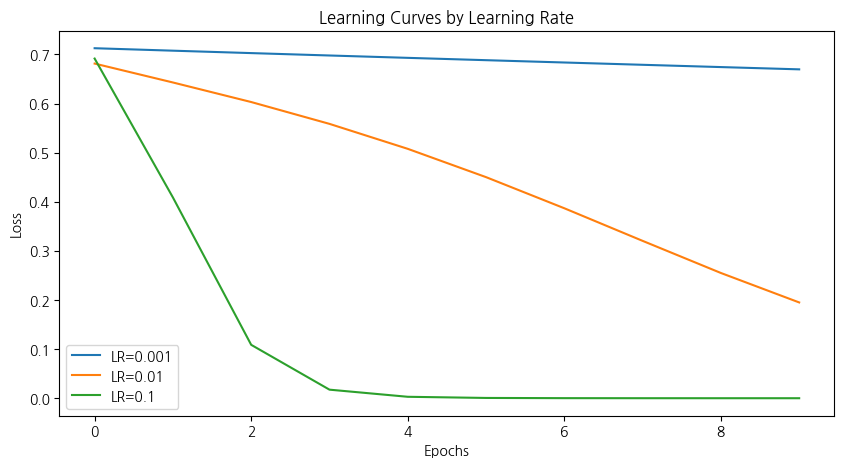

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. 모델 정의 (LSTM 구조)
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        # lstm_out: (batch, seq_len, hidden_dim)
        # hidden: (1, batch, hidden_dim)
        _, (hidden, _) = self.lstm(embedded)
        # 마지막 시점의 은닉 상태만 사용하여 분류
        out = self.fc(hidden.squeeze(0))
        return self.sigmoid(out)

# 2. 실험을 위한 학습 함수
def train_and_evaluate(embedding_dim, hidden_dim, learning_rate, epochs=10):
    # 가상의 데이터 설정
    vocab_size = 100
    output_dim = 1
    # 샘플 데이터 (batch_size=8, seq_len=5)
    inputs = torch.randint(0, vocab_size, (8, 5))
    labels = torch.FloatTensor([[1], [0], [1], [0], [1], [0], [1], [0]])

    model = SentimentLSTM(vocab_size, embedding_dim, hidden_dim, output_dim)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions = model(inputs)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    # 마지막 정확도 계산 (가상)
    with torch.no_grad():
        preds = (predictions > 0.5).float()
        accuracy = (preds == labels).sum().item() / labels.size(0)

    return loss_history, accuracy

# --- 실험 1: EMBEDDING_DIM 변경 ---
results_emb = {}
for dim in [8, 16, 32]:
    _, acc = train_and_evaluate(embedding_dim=dim, hidden_dim=32, learning_rate=0.01)
    results_emb[dim] = acc
    print(f"Embedding Dim {dim}: Accuracy {acc}")

# --- 실험 3: learning_rate 변경 및 학습 곡선 시각화 ---
plt.figure(figsize=(10, 5))
for lr in [0.001, 0.01, 0.1]:
    loss_hist, _ = train_and_evaluate(embedding_dim=16, hidden_dim=32, learning_rate=lr)
    plt.plot(loss_hist, label=f'LR={lr}')

plt.title("Learning Curves by Learning Rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 과제 2: 양방향 LSTM (도전)

`nn.LSTM`에 `bidirectional=True`를 추가하면 문장을 **양방향**으로 읽습니다.  
단방향 LSTM과 양방향 LSTM의 성능을 비교해보세요.

```python
# 힌트
self.lstm = nn.LSTM(
    input_size=embedding_dim,
    hidden_size=hidden_dim,
    batch_first=True,
    bidirectional=True  # 양방향!
)
# 주의: 출력 크기가 hidden_dim * 2가 됩니다
self.fc = nn.Linear(hidden_dim * 2, 1)
```

In [6]:
# 1️⃣2️⃣ 학습 데이터 준비
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 간단한 영화 리뷰 데이터 (실습용)
reviews = [
    # (리뷰, 레이블)  1=긍정, 0=부정
    ("이 영화 정말 재미있다 최고의 영화", 1),
    ("배우 연기가 훌륭하고 스토리도 좋다", 1),
    ("감동적인 영화 눈물이 났다", 1),
    ("올해 최고의 영화 강추한다", 1),
    ("재미있고 감동적이다 또 보고 싶다", 1),
    ("연출이 뛰어나고 음악도 좋다", 1),
    ("완벽한 영화 모든 것이 좋았다", 1),
    ("시간 가는 줄 모르고 봤다 재미있다", 1),
    ("이 영화 정말 지루하다 별로다", 0),
    ("스토리가 너무 진부하고 재미없다", 0),
    ("시간 낭비 돈 아깝다", 0),
    ("연기가 어색하고 내용이 별로다", 0),
    ("최악의 영화 다시는 안 본다", 0),
    ("지루하고 졸렸다 비추천한다", 0),
    ("기대했는데 실망이다 별로다", 0),
    ("돈이 아깝다 최악이다", 0),
]

print(f"전체 데이터 수: {len(reviews)}개")
print(f"긍정: {sum(1 for _, l in reviews if l == 1)}개")
print(f"부정: {sum(1 for _, l in reviews if l == 0)}개")

전체 데이터 수: 16개
긍정: 8개
부정: 8개


In [7]:
# 1️⃣3️⃣ 어휘 사전 만들기 (단어 → 정수 변환)

# 모든 단어 수집
all_words = []
for text, _ in reviews:
    all_words.extend(text.split())

# 고유 단어 → 인덱스 매핑
vocab = sorted(set(all_words))
word2idx = {word: idx + 2 for idx, word in enumerate(vocab)}
word2idx["<PAD>"] = 0  # 패딩 토큰
word2idx["<UNK>"] = 1  # 미등록 단어

idx2word = {idx: word for word, idx in word2idx.items()}

print(f"어휘 크기: {len(word2idx)}개")
print(f"\n어휘 사전 (처음 10개):")
for word, idx in list(word2idx.items())[:10]:
    print(f"  '{word}' → {idx}")

어휘 크기: 56개

어휘 사전 (처음 10개):
  '가는' → 2
  '감동적이다' → 3
  '감동적인' → 4
  '강추한다' → 5
  '것이' → 6
  '기대했는데' → 7
  '났다' → 8
  '낭비' → 9
  '내용이' → 10
  '너무' → 11


In [8]:
# 1️⃣4️⃣ 문장을 정수 시퀀스로 변환 + 패딩

def encode_sentence(text, word2idx, max_len=10):
    '''문장을 정수 리스트로 변환하고 패딩 적용'''
    tokens = text.split()
    indices = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

    # 패딩: max_len보다 짧으면 0으로 채우기
    if len(indices) < max_len:
        indices = indices + [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]  # 너무 길면 자르기

    return indices

# 테스트
test_sentence = "이 영화 정말 재미있다 최고의 영화"
encoded = encode_sentence(test_sentence, word2idx)

print(f"원문: {test_sentence}")
print(f"토큰: {test_sentence.split()}")
print(f"인코딩: {encoded}")
print()
print("💡 각 숫자는 어휘 사전의 인덱스입니다")
print("💡 뒤의 0들은 패딩(PAD) — 길이를 맞추기 위한 빈칸")

원문: 이 영화 정말 재미있다 최고의 영화
토큰: ['이', '영화', '정말', '재미있다', '최고의', '영화']
인코딩: [40, 36, 44, 43, 52, 36, 0, 0, 0, 0]

💡 각 숫자는 어휘 사전의 인덱스입니다
💡 뒤의 0들은 패딩(PAD) — 길이를 맞추기 위한 빈칸


In [9]:
# 1️⃣5️⃣ 전체 데이터를 텐서로 변환
import torch

MAX_LEN = 10

X_data = []
y_data = []

for text, label in reviews:
    encoded = encode_sentence(text, word2idx, MAX_LEN)
    X_data.append(encoded)
    y_data.append(label)

X_tensor = torch.tensor(X_data, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.float32)

print(f"X 형태: {X_tensor.shape}")  # (16, 10) — 16문장, 최대 10단어
print(f"y 형태: {y_tensor.shape}")  # (16,)
print(f"\nX 첫 번째 샘플: {X_tensor[0]}")
print(f"y 첫 번째 레이블: {y_tensor[0]} (긍정)")

X 형태: torch.Size([16, 10])
y 형태: torch.Size([16])

X 첫 번째 샘플: tensor([40, 36, 44, 43, 52, 36,  0,  0,  0,  0])
y 첫 번째 레이블: 1.0 (긍정)


In [15]:
# 1️⃣6️⃣ LSTM 감성 분류 모델
import torch
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # 1. 임베딩: 정수 → 밀집 벡터
        #    "단어 3번" → [0.2, -0.5, 0.1, ...] (embedding_dim 차원)
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0  # PAD(0)는 항상 영벡터
        )

        # 2. LSTM: 순서를 반영하여 문장 이해
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True  # 양방향!
        )

        # 3. 분류층: LSTM 출력 → 긍정/부정 확률
        # 주의: 출력 크기가 hidden_dim * 2가 됩니다
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x 형태: (배치, 문장길이) — 정수 시퀀스

        # Step 1: 임베딩
        embedded = self.embedding(x)
        # embedded 형태: (배치, 문장길이, embedding_dim)

        # Step 2: LSTM
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        # h_n 형태: (1, 배치, hidden_dim)

        # Step 3: 마지막 은닉 상태로 분류
        # last_hidden = h_n.squeeze(0)  # (배치, hidden_dim)
        last_hidden = torch.cat((h_n[0], h_n[1]), dim=1) # 결과: (배치, hidden_dim * 2)
        output = self.fc(last_hidden) # (배치, 1)
        output = self.sigmoid(output) # 0~1 확률

        return output.squeeze(1)      # (배치,)

# 모델 생성
VOCAB_SIZE = len(word2idx)
EMBEDDING_DIM = 16
HIDDEN_DIM = 32

model = SentimentLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM)
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}개")

SentimentLSTM(
  (embedding): Embedding(56, 16, padding_idx=0)
  (lstm): LSTM(16, 32, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

총 파라미터 수: 13,761개


In [16]:
# 1️⃣7️⃣ 학습 루프
import torch
import torch.nn as nn

# 손실 함수 & 옵티마이저
criterion = nn.BCELoss()              # Binary Cross-Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 학습 시작
EPOCHS = 100

print("=== 학습 시작 ===")
for epoch in range(EPOCHS):
    model.train()

    # 순전파
    predictions = model(X_tensor)        # 모델 예측
    loss = criterion(predictions, y_tensor)  # 손실 계산

    # 역전파
    optimizer.zero_grad()  # 이전 기울기 초기화
    loss.backward()        # 기울기 계산
    optimizer.step()       # 가중치 업데이트

    # 정확도 계산
    predicted_labels = (predictions >= 0.5).float()
    accuracy = (predicted_labels == y_tensor).float().mean()

    # 10 에포크마다 출력
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | 손실: {loss.item():.4f} | 정확도: {accuracy.item():.2%}")

print("\n=== 학습 완료! ===")

=== 학습 시작 ===
  Epoch  10/100 | 손실: 0.1368 | 정확도: 100.00%
  Epoch  20/100 | 손실: 0.0031 | 정확도: 100.00%
  Epoch  30/100 | 손실: 0.0005 | 정확도: 100.00%
  Epoch  40/100 | 손실: 0.0004 | 정확도: 100.00%
  Epoch  50/100 | 손실: 0.0004 | 정확도: 100.00%
  Epoch  60/100 | 손실: 0.0003 | 정확도: 100.00%
  Epoch  70/100 | 손실: 0.0002 | 정확도: 100.00%
  Epoch  80/100 | 손실: 0.0002 | 정확도: 100.00%
  Epoch  90/100 | 손실: 0.0002 | 정확도: 100.00%
  Epoch 100/100 | 손실: 0.0001 | 정확도: 100.00%

=== 학습 완료! ===


In [17]:
# 1️⃣8️⃣ 새로운 문장으로 테스트

def predict_sentiment(text, model, word2idx, max_len=10):
    '''새로운 문장의 감성을 예측'''
    model.eval()

    # 인코딩
    encoded = encode_sentence(text, word2idx, max_len)
    input_tensor = torch.tensor([encoded], dtype=torch.long)

    # 예측
    with torch.no_grad():
        prob = model(input_tensor).item()

    sentiment = "긍정 😊" if prob >= 0.5 else "부정 😞"
    return prob, sentiment

# 테스트 문장들
test_sentences = [
    "정말 재미있다 최고의 영화",
    "지루하고 별로다 실망이다",
    "연기가 좋고 감동적이다",
    "시간 낭비 최악이다",
    "영화 재미있고 좋다",
]

print("=== 감성 분석 결과 ===")
print()
for sentence in test_sentences:
    prob, sentiment = predict_sentiment(sentence, model, word2idx)
    print(f" {sentence}")
    print(f"  → {sentiment} (확률: {prob:.2%})")
    print()

=== 감성 분석 결과 ===

 정말 재미있다 최고의 영화
  → 긍정 😊 (확률: 100.00%)

 지루하고 별로다 실망이다
  → 부정 😞 (확률: 0.03%)

 연기가 좋고 감동적이다
  → 부정 😞 (확률: 0.95%)

 시간 낭비 최악이다
  → 부정 😞 (확률: 0.10%)

 영화 재미있고 좋다
  → 긍정 😊 (확률: 100.00%)

